
**Complete Pipeline for GLUE Uncertainty Quantification on d-HyMoLAP parameters for CAMELS-FR and CAMELS-GB datasets**

**Author:** Lionel Cedric Gohouede


In [ ]:
pip install aqua-fetch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.1/289.1 kB 10.0 MB/s eta 0:00:00



        Not downloading the data since the directory 
        /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_FR already exists.
        Use overwrite=True to remove previously saved files and download again
P392252001  not found in site_general_attributes.csv
P613402001  not found in site_general_attributes.csv
Read 654 stations for 22 dyn features in 42.28 seconds with 2 cpus.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Station       Δμ        Δλ        ΔQs        Δqs  n_beh     PICP     MPIW
A251020001 0.910782 43.089603  20.099293 134.948008    233 0.766487 0.080763
H774202001 1.086699 92.582991  68.888587  44.065099   1434 0.883036 0.225531
     39049 0.849797 86.072903  14.503838  97.792597     42 0.818978 0.053384
     27007 0.750945 24.648238

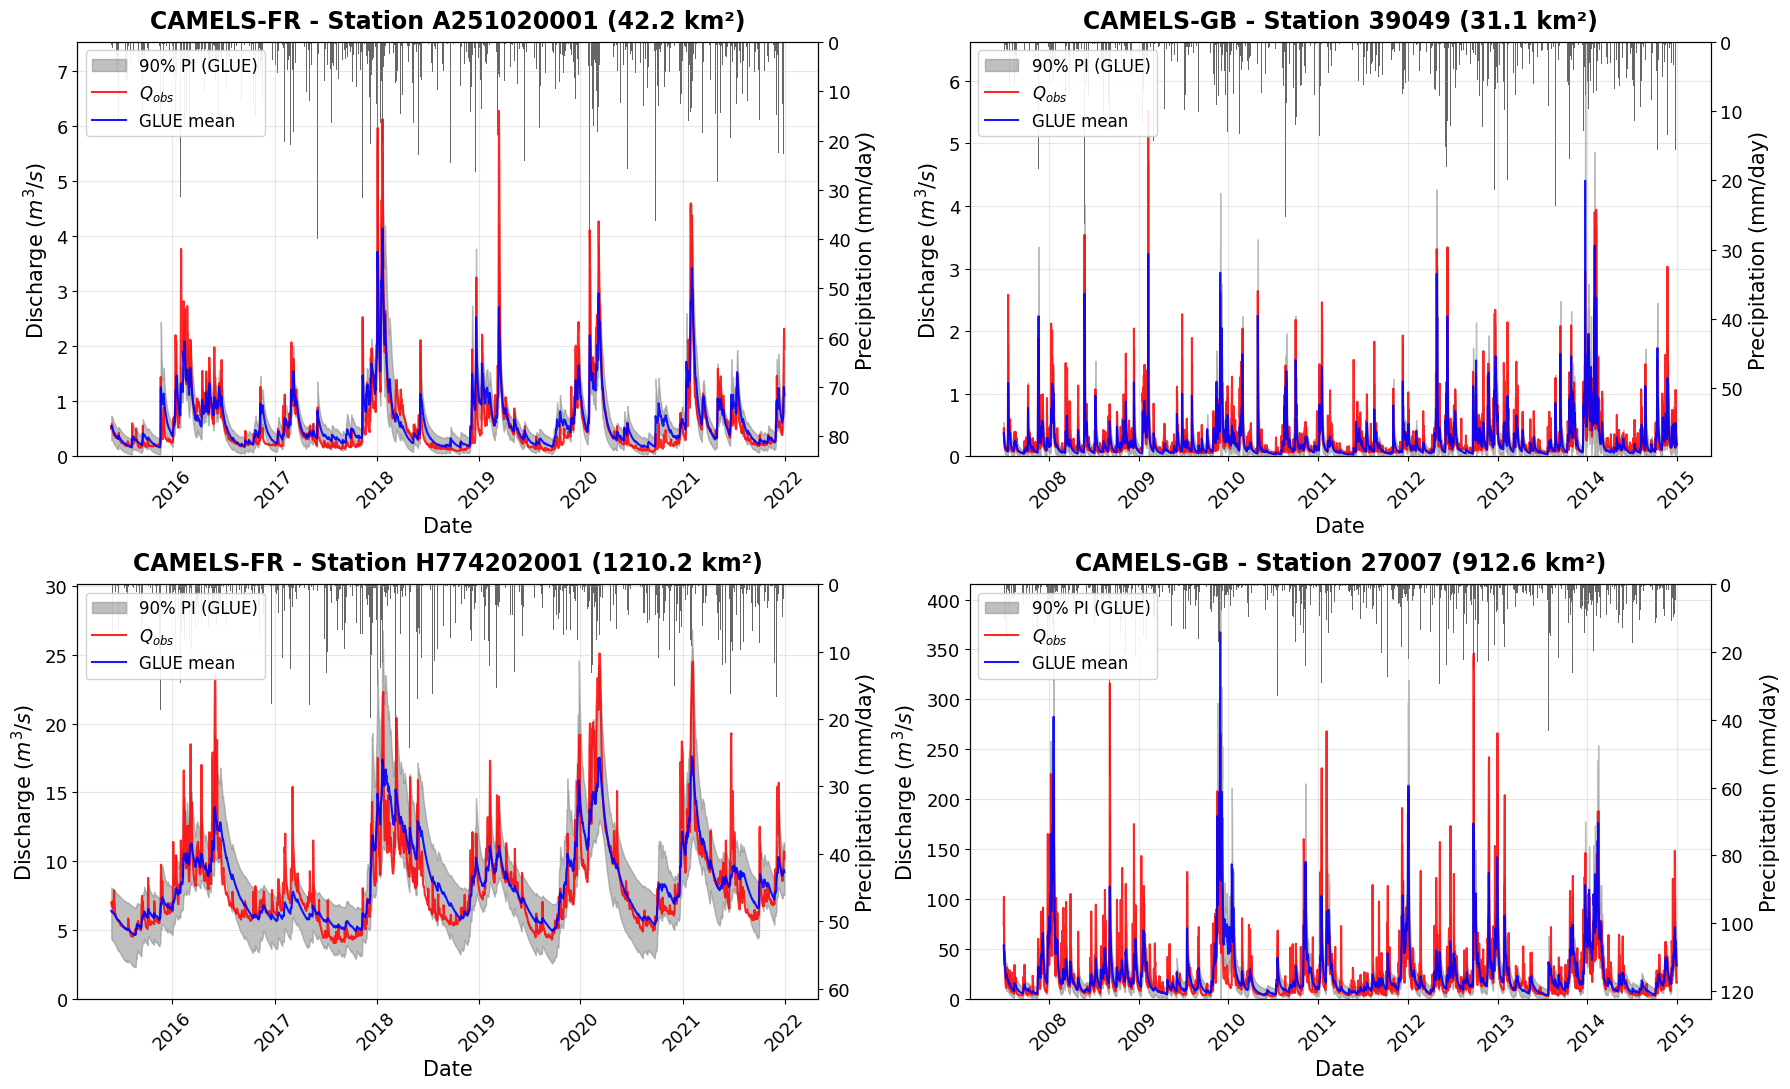

In [ ]:
!pip install -q numba

import warnings
warnings.filterwarnings("ignore", message="netCDF4 module is not installed")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit, prange
from aqua_fetch import RainfallRunoff

# ============================================================================
# CONFIGURATION
# ============================================================================
QUANTILES      = [0.1, 0.9]
CALIB_RATIO    = 0.70
TIME_PERIOD_FR = ("2000-01-01", "2021-12-31")
TIME_PERIOD_GB = ("1990-01-01", "2014-12-31")
DATA_DIR_GB    = '/content/drive/MyDrive/Colab Notebooks/CAMELS_GB/'

N_SAMPLES  = 100_000
NSE_THRESH = 0.5
PI_LOW, PI_HIGH = 5, 95   # 90% prediction interval

np.random.seed(42)

def safe_nanmax(arr, default=1.0):
    """nanmax that never returns NaN/Inf; falls back to default if all-NaN or empty."""
    if arr.size == 0 or np.all(np.isnan(arr)):
        return default
    val = np.nanmax(arr)
    return val if np.isfinite(val) and val > 0 else default

def all_nan(arr):
    return arr.size == 0 or np.all(np.isnan(arr))

# ============================================================================
# QUANTILE CATCHMENT SELECTION
# ============================================================================
def find_quantile_catchments(df, area_col, id_col, quantiles):
    df_valid = df[df[area_col].notna()].copy()
    results = {}
    for q in quantiles:
        q_value = np.percentile(df_valid[area_col], q * 100)
        diff = np.abs(df_valid[area_col] - q_value)
        idx = diff.idxmin()
        results[f'q{int(q*100):02d}'] = {
            'station_id': str(df_valid.loc[idx, id_col]),
            'area_km2': float(df_valid.loc[idx, area_col])
        }
    return results

# ============================================================================
# d-HyMoLAP MODEL (numba jitted core) - params: mu, lambda_, Qs, qs
# ============================================================================
@njit(cache=True)
def d_HyMoLAP_core(mu, lambda_, Qs, qs, Q0, q):
    n = q.shape[0]
    k = np.zeros(n)
    x = np.zeros(n)
    k[0] = Q0 / Qs if Qs > 0 else 0.0

    for t in range(n - 1):
        qtp1 = q[t + 1]
        if np.isnan(qtp1):
            k[t + 1] = k[t]
            x[t + 1] = x[t]
            continue
        r_tp1 = qtp1 / qs if qs != 0 else 0.0

        if r_tp1 > 0:
            x[t + 1] = x[t] + (mu / lambda_) * r_tp1
        else:
            x[t + 1] = (1 - (mu / lambda_)) * x[t]

        k[t + 1] = max(0.0, k[t] - (mu / lambda_) * k[t] ** (2 * mu - 1) +
                        (1 / lambda_) * x[t + 1] * r_tp1)
    return k * Qs

@njit(cache=True)
def nse_core(obs, sim):
    n = obs.shape[0]
    o_sum, cnt = 0.0, 0
    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            o_sum += obs[i]
            cnt += 1
    if cnt == 0:
        return -1e6
    o_mean = o_sum / cnt
    num, den = 0.0, 0.0
    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i]) ** 2
            den += (obs[i] - o_mean) ** 2
    if den == 0:
        return -1e6
    return 1.0 - num / den

@njit(parallel=True, cache=True)
def batch_nse(param_array, Q0, q_train, Qobs_train):
    n = param_array.shape[0]
    nse_arr = np.empty(n)
    for i in prange(n):
        sim = d_HyMoLAP_core(param_array[i, 0], param_array[i, 1],
                              param_array[i, 2], param_array[i, 3],
                              Q0, q_train)
        nse_arr[i] = nse_core(Qobs_train, sim)
    return nse_arr

@njit(parallel=True, cache=True)
def batch_simulate_full(param_array, Q0, q_full):
    n = param_array.shape[0]
    N = q_full.shape[0]
    sims = np.empty((n, N))
    for i in prange(n):
        sims[i, :] = d_HyMoLAP_core(param_array[i, 0], param_array[i, 1],
                                     param_array[i, 2], param_array[i, 3],
                                     Q0, q_full)
    return sims

# ============================================================================
# GLUE ROUTINE FOR ONE STATION
# ============================================================================
def glue_station(P, PET, Q_obs, time, calib_ratio=CALIB_RATIO):
    q = np.maximum(0, P - PET)
    N = len(Q_obs)
    b1 = int(N * calib_ratio)
    Q0 = Q_obs[0] if not np.isnan(Q_obs[0]) else np.nanmean(Q_obs[:b1])
    if np.isnan(Q0):
        Q0 = 0.0

    q_train = q[:b1].astype(np.float64)
    Qobs_train = Q_obs[:b1].astype(np.float64)

    # bounds order matches params order: mu, lambda_, Qs, qs
    # safe_nanmax guards against all-NaN calibration windows
    bounds = [
        (0.5, 2), (1, 100),
        (0.001, 2 * safe_nanmax(Qobs_train)),
        (0.001, 2 * safe_nanmax(q_train))
    ]

    param_samples = np.column_stack([
        np.random.uniform(lo, hi, N_SAMPLES) for lo, hi in bounds
    ])

    nse_arr = batch_nse(param_samples, Q0, q_train, Qobs_train)

    behavioral_mask = nse_arr >= NSE_THRESH
    n_beh = int(behavioral_mask.sum())
    beh_params = param_samples[behavioral_mask]

    q_full = q.astype(np.float64)

    if n_beh == 0:
        N_full = len(q_full)
        Q_mean = np.full(N_full, np.nan)
        Q_lower = np.full(N_full, np.nan)
        Q_upper = np.full(N_full, np.nan)
    else:
        sims_full = batch_simulate_full(beh_params, Q0, q_full)
        Q_mean = np.mean(sims_full, axis=0)
        Q_lower = np.percentile(sims_full, PI_LOW, axis=0)
        Q_upper = np.percentile(sims_full, PI_HIGH, axis=0)

    obs_val = Q_obs[b1:]
    lower_val = Q_lower[b1:]
    upper_val = Q_upper[b1:]

    # guard: validation window may be entirely NaN (data gaps)
    valid = ~np.isnan(obs_val) & ~np.isnan(lower_val) & ~np.isnan(upper_val)
    if valid.sum() == 0:
        picp = np.nan
        mpiw = np.nan
    else:
        picp = np.mean((obs_val[valid] >= lower_val[valid]) &
                       (obs_val[valid] <= upper_val[valid]))
        obs_range = safe_nanmax(obs_val[valid], default=np.nan) - np.nanmin(obs_val[valid]) \
                    if not all_nan(obs_val[valid]) else np.nan
        mpiw = np.mean(upper_val[valid] - lower_val[valid]) / obs_range \
               if (not np.isnan(obs_range) and obs_range > 0) else np.nan

    delta_mu = beh_params[:, 0].max() - beh_params[:, 0].min() if n_beh else np.nan
    delta_lambda = beh_params[:, 1].max() - beh_params[:, 1].min() if n_beh else np.nan
    delta_Qs = beh_params[:, 2].max() - beh_params[:, 2].min() if n_beh else np.nan
    delta_qs = beh_params[:, 3].max() - beh_params[:, 3].min() if n_beh else np.nan

    return {
        'time': time, 'P': P, 'Q_obs': Q_obs, 'b1': b1,
        'Q_mean': Q_mean, 'Q_lower': Q_lower, 'Q_upper': Q_upper,
        'n_beh': n_beh, 'PICP': picp, 'MPIW': mpiw,
        'delta_mu': delta_mu, 'delta_lambda': delta_lambda,
        'delta_Qs': delta_Qs, 'delta_qs': delta_qs
    }

def glue_station_FR(ds, station_id, calib_ratio=CALIB_RATIO):
    Q_obs = 1/1000 * ds[station_id].sel(dynamic_features="q_cms_obs").to_numpy()
    P = ds[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET = ds[station_id].sel(dynamic_features="pet_mm_pm").to_numpy()
    time = ds[station_id].coords["time"].to_numpy()
    return glue_station(P, PET, Q_obs, time, calib_ratio)

def glue_station_GB(station_id, df_pcp, df_pet, df_q, calib_ratio=CALIB_RATIO):
    P = df_pcp[station_id].values
    PET = df_pet[station_id].values
    Q_obs = df_q[station_id].values
    time = df_pcp.index.values
    return glue_station(P, PET, Q_obs, time, calib_ratio)

# ============================================================================
# STEP 1: LOAD CAMELS-FR
# ============================================================================
rr_fr = RainfallRunoff("CAMELS_FR")
meta_fr, ds_fr = rr_fr.fetch()
ds_fr = ds_fr.sel(time=slice(*TIME_PERIOD_FR))

# ============================================================================
# STEP 2: QUANTILE CATCHMENTS - CAMELS-FR
# ============================================================================
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Data")
fr_meta = pd.read_csv(DATA_DIR / 'CAMELS_FR_station_general_attributes.csv', sep=';')
fr_quantiles = find_quantile_catchments(fr_meta, 'sta_area_snap', 'sta_code_h3', [0.1, 0.90125])

# ============================================================================
# STEP 3: LOAD CAMELS-GB
# ============================================================================
try:
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

df_pcp_gb = pd.read_csv(DATA_DIR_GB + 'pcp_mm.csv', index_col=0, parse_dates=True)
df_pet_gb = pd.read_csv(DATA_DIR_GB + 'pet_mm.csv', index_col=0, parse_dates=True)
df_q_gb = pd.read_csv(DATA_DIR_GB + 'q_cms_obs.csv', index_col=0, parse_dates=True)

df_pcp_gb = df_pcp_gb.loc[TIME_PERIOD_GB[0]:TIME_PERIOD_GB[1]]
df_pet_gb = df_pet_gb.loc[TIME_PERIOD_GB[0]:TIME_PERIOD_GB[1]]
df_q_gb = df_q_gb.loc[TIME_PERIOD_GB[0]:TIME_PERIOD_GB[1]]

# ============================================================================
# STEP 4: QUANTILE CATCHMENTS - CAMELS-GB
# ============================================================================
gb_meta = pd.read_csv(DATA_DIR / 'CAMELS_GB_topographic_attributes.csv')
gb_quantiles = find_quantile_catchments(gb_meta, 'area', 'gauge_id', QUANTILES)

# ============================================================================
# STEP 5: RUN GLUE FOR ALL QUANTILE CATCHMENTS
# ============================================================================
results = {}
summary_rows = []

for q_key, q_data in fr_quantiles.items():
    station_id = q_data['station_id']
    res = glue_station_FR(ds_fr, station_id)
    results[f"CAMELS_FR_{q_key}"] = {**res, 'dataset': 'CAMELS-FR',
                                      'area': q_data['area_km2'], 'station_id': station_id}
    summary_rows.append([station_id, res['delta_mu'], res['delta_lambda'],
                          res['delta_Qs'], res['delta_qs'],
                          res['n_beh'], res['PICP'], res['MPIW']])

for q_key, q_data in gb_quantiles.items():
    station_id = q_data['station_id']
    res = glue_station_GB(station_id, df_pcp_gb, df_pet_gb, df_q_gb)
    results[f"CAMELS_GB_{q_key}"] = {**res, 'dataset': 'CAMELS-GB',
                                      'area': q_data['area_km2'], 'station_id': station_id}
    summary_rows.append([station_id, res['delta_mu'], res['delta_lambda'],
                          res['delta_Qs'], res['delta_qs'],
                          res['n_beh'], res['PICP'], res['MPIW']])

summary_df = pd.DataFrame(
    summary_rows,
    columns=['Station', 'Δμ', 'Δλ', 'ΔQs', 'Δqs', 'n_beh', 'PICP', 'MPIW']
)
print(summary_df.to_string(index=False))

# ============================================================================
# STEP 6: PLOTTING - 90% PI (gray) + GLUE mean (blue)
# ============================================================================
n_quantiles = len(QUANTILES)
fig, axes = plt.subplots(2, n_quantiles, figsize=(9*n_quantiles, 11))
if n_quantiles == 1:
    axes = axes.reshape(2, 1)
axes = axes.flatten()

plot_order = []
for q_key in [f'q{int(q*100):02d}' for q in QUANTILES]:
    plot_order.append(f'CAMELS_FR_{q_key}')
    plot_order.append(f'CAMELS_GB_{q_key}')

FONT = 15

for idx, key in enumerate(plot_order):
    if key not in results:
        continue

    res = results[key]
    ax1 = axes[idx]

    time = res['time']
    P = res['P']
    Q_obs = res['Q_obs']
    b1 = res['b1']

    dataset = res['dataset']
    area = res['area']
    station_id = res['station_id']

    # guard: validation-period observations entirely missing
    if all_nan(Q_obs[b1:]):
        ax1.text(0.5, 0.5, f"No observed data\nin validation period\n({dataset} {station_id})",
                  ha='center', va='center', transform=ax1.transAxes, fontsize=FONT)
        ax1.set_title(f"{dataset} - Station {station_id} ({area:.1f} km²)",
                       fontsize=FONT+2, fontweight='bold', pad=10)
        ax1.set_xticks([])
        ax1.set_yticks([])
        continue

    Q_mean = res['Q_mean']
    Q_lower = res['Q_lower']
    Q_upper = res['Q_upper']

    ax1.fill_between(time[b1:], Q_lower[b1:], Q_upper[b1:],
                      color='gray', alpha=0.5, label='90% PI (GLUE)')
    ax1.plot(time[b1:], Q_obs[b1:], 'r-', linewidth=1.5, label='$Q_{obs}$', alpha=0.85)
    ax1.plot(time[b1:], Q_mean[b1:], 'b-', linewidth=1.5, label='GLUE mean', alpha=0.9)

    ax1.set_ylabel(r'Discharge ($m^3/s$)', color='black', fontsize=FONT)
    ax1.tick_params(axis='y', labelcolor='black', labelsize=FONT-2)
    ax1.set_ylim(0, safe_nanmax(Q_obs[b1:]) * 1.2)
    ax1.set_xlabel('Date', fontsize=FONT)
    ax1.tick_params(axis='x', rotation=45, labelsize=FONT-2)

    ax2 = ax1.twinx()
    ax2.bar(time[b1:], P[b1:], color='black', alpha=0.6, width=1.0, edgecolor='none')
    ax2.set_ylabel('Precipitation (mm/day)', color='black', fontsize=FONT)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=FONT-2)
    ax2.set_ylim(0, safe_nanmax(P[b1:], default=100.0) * 1.5)
    ax2.invert_yaxis()

    ax1.set_title(f"{dataset} - Station {station_id} ({area:.1f} km²)",
                   fontsize=FONT+2, fontweight='bold', pad=10)

    ax1.legend(loc='upper left', fontsize=FONT-3, framealpha=0.9)
    ax1.grid(True, alpha=0.3, zorder=0)
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

plt.tight_layout()
plt.savefig('glue_quantile_catchments.pdf', dpi=300, bbox_inches='tight')
plt.show()